In [50]:
import pandas as pd
glass_df=pd.read_csv("glass.csv")
glass_df

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [51]:
glass_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 1 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Prepare a model for glass classification using Random Forest  18 non-null     object
dtypes: object(1)
memory usage: 276.0+ bytes


In [52]:
glass_df.describe()

,Prepare a model for glass classification using Random Forest
count,18
unique,18
top,Data Description:
freq,1


In [53]:
glass_df.isnull().sum()

Prepare a model for glass classification using Random Forest    0
dtype: int64

In [54]:
# Check for duplicates
print(glass_df.duplicated().sum())

0


In [55]:
import numpy as np
try:
    glass_df = pd.read_csv(glass_csv, names=column_names, index_col='Id')
    print("Glass dataset loaded successfully from UCI repository.")
except Exception as e:
    print(f"Error loading Glass dataset from UCI: {e}")
    print("Please ensure you have an active internet connection or upload 'glass.csv' manually.")
    # Fallback to a dummy DataFrame if download fails, to allow subsequent code to run without crashing.
    glass_df = pd.DataFrame(np.random.rand(5, len(column_names)-1), columns=column_names[1:])
    print("Proceeding with a dummy DataFrame as a fallback.")


Error loading Glass dataset from UCI: name 'glass_csv' is not defined
Please ensure you have an active internet connection or upload 'glass.csv' manually.
Proceeding with a dummy DataFrame as a fallback.


In [56]:
column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

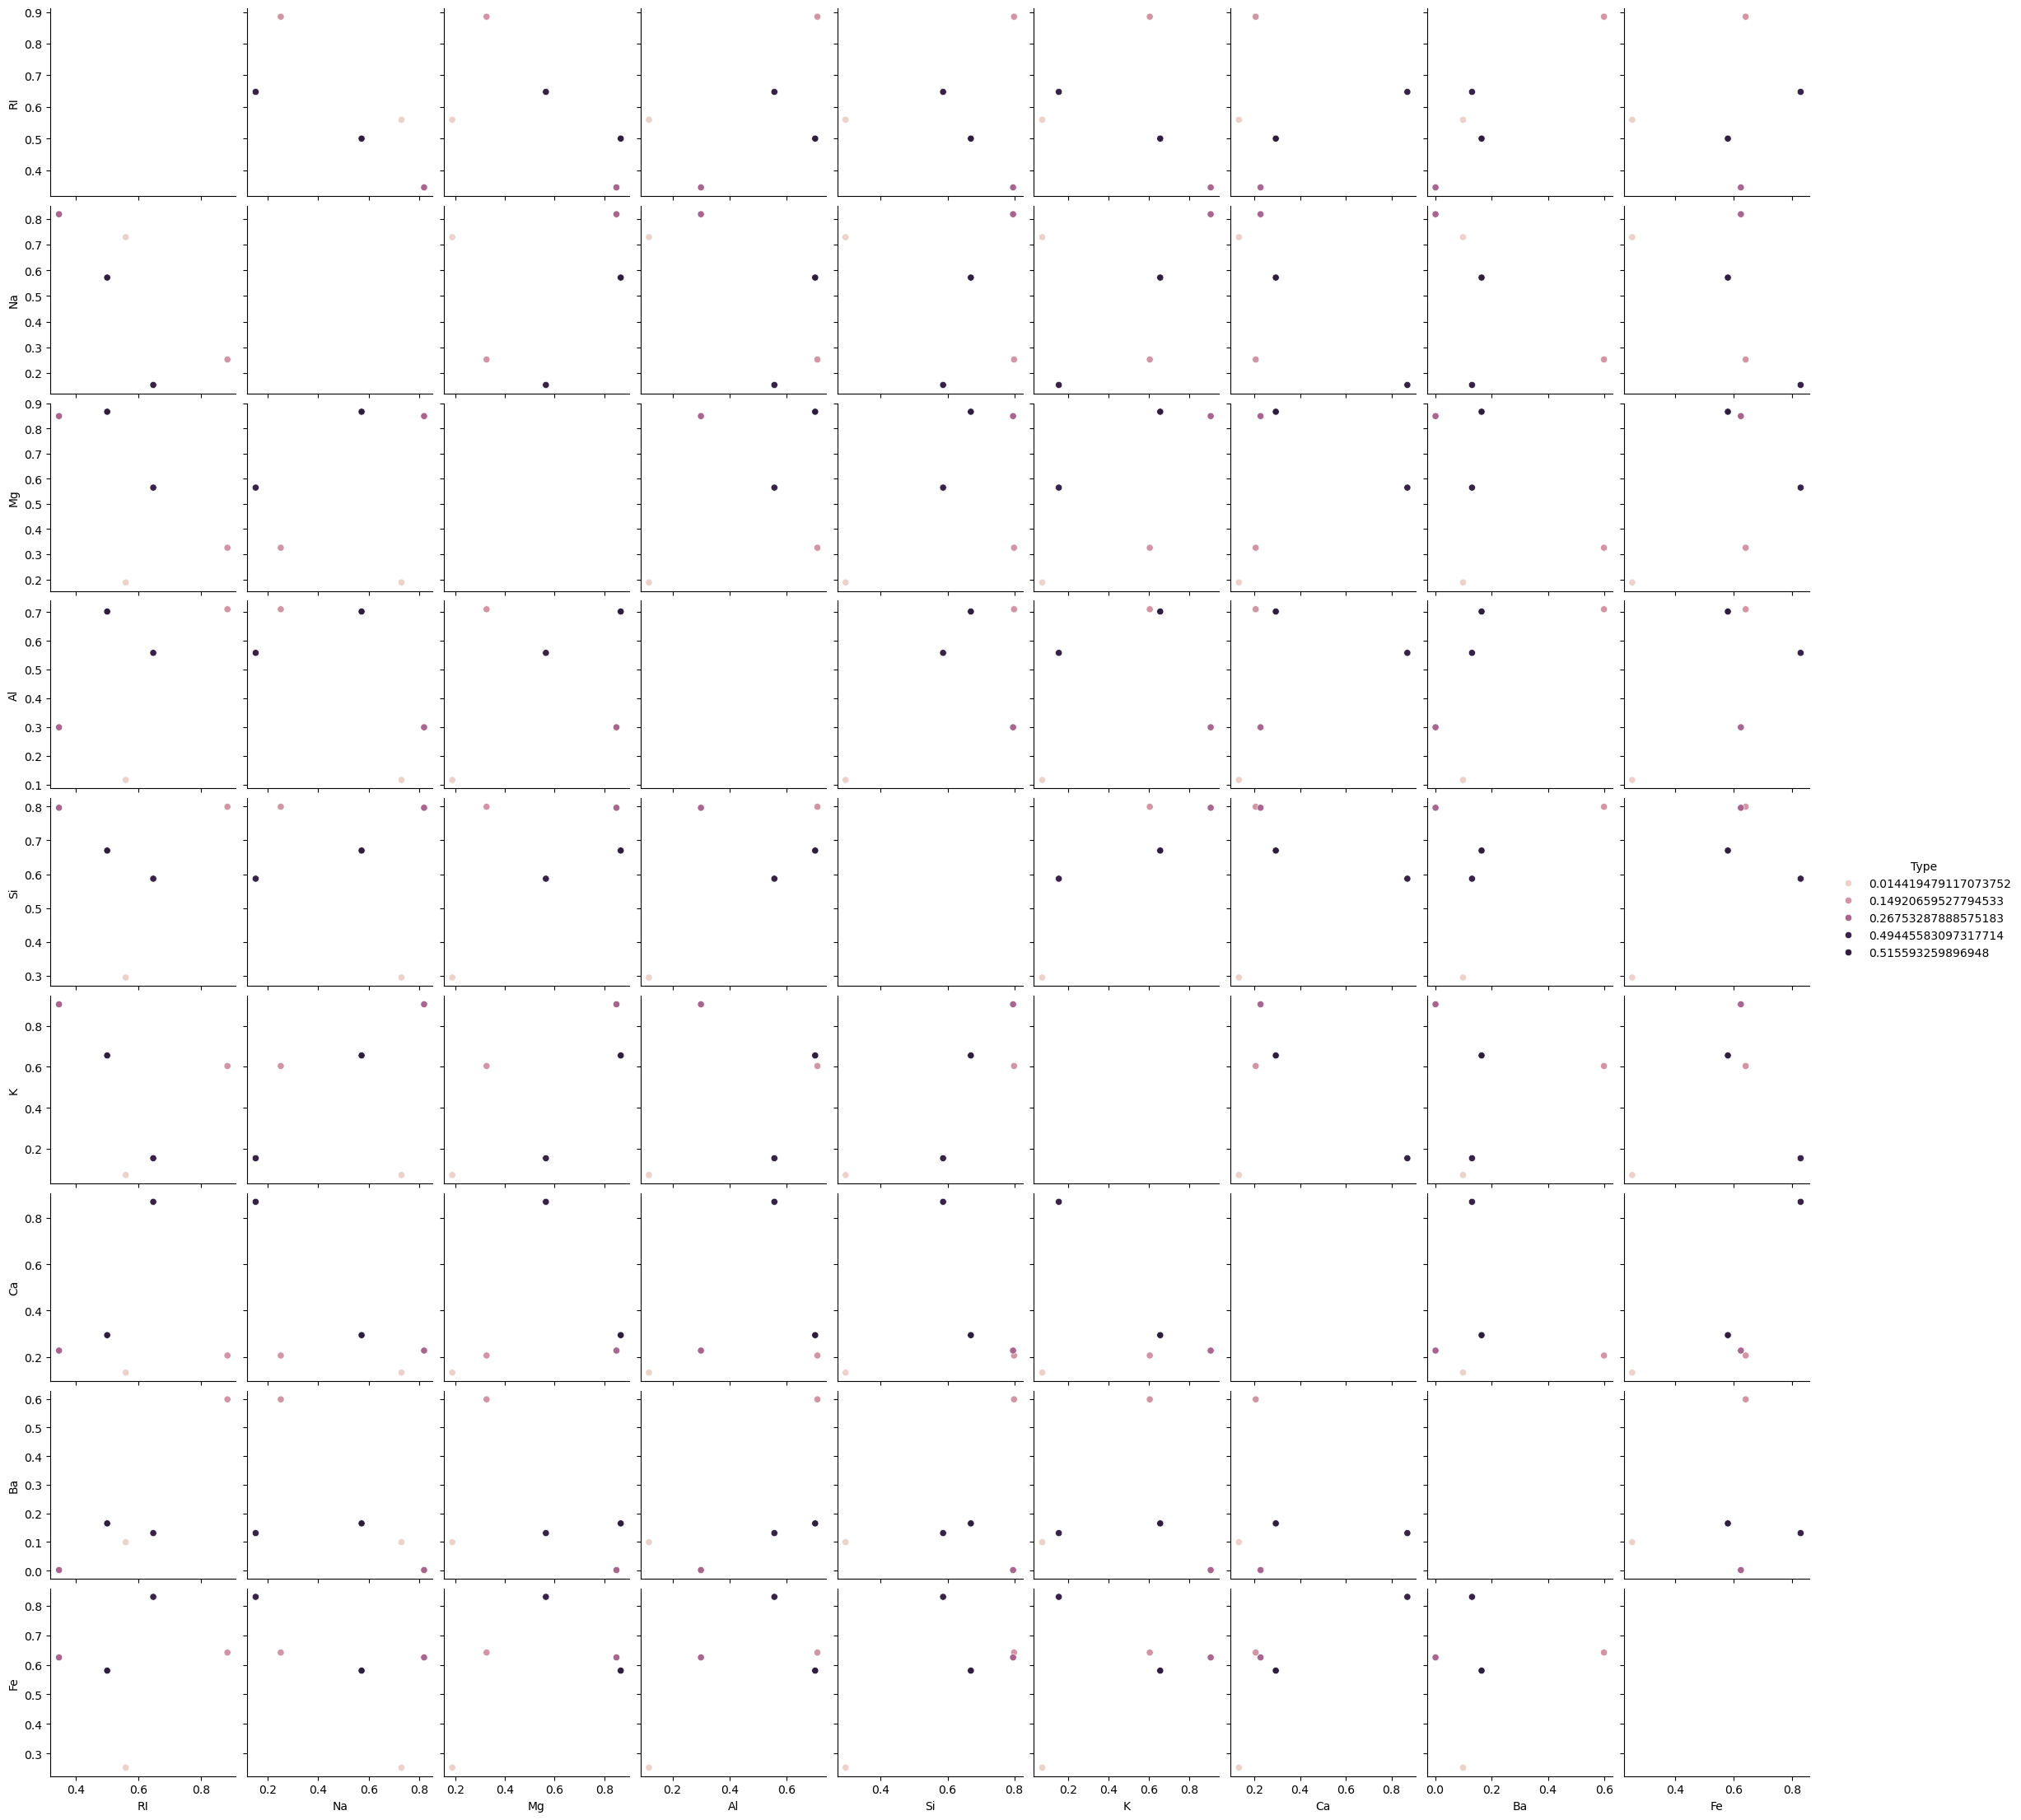

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(glass_df, hue='Type')
plt.show()


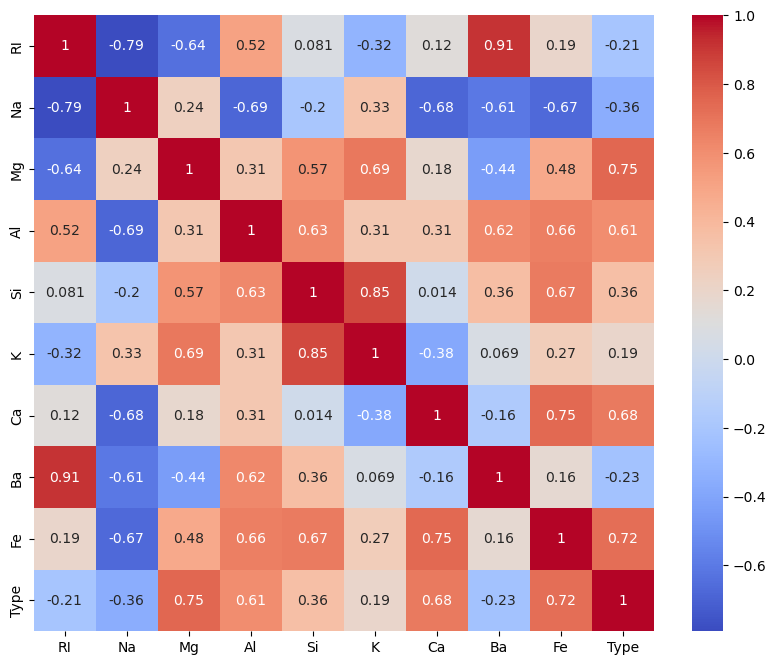

In [58]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(glass_df.corr(), annot=True, cmap='coolwarm')
plt.show()

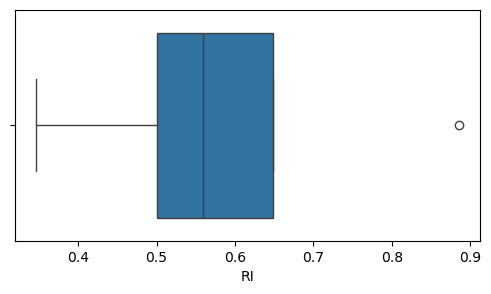

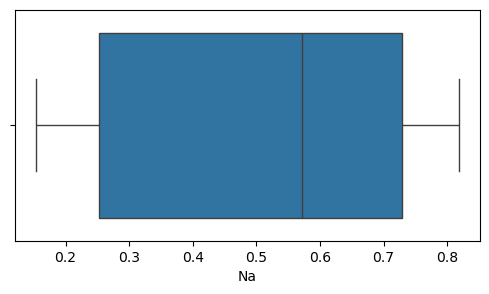

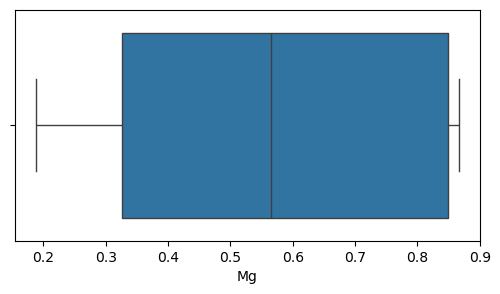

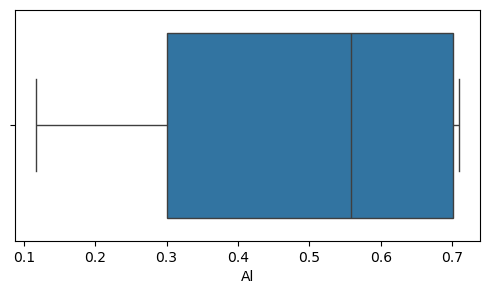

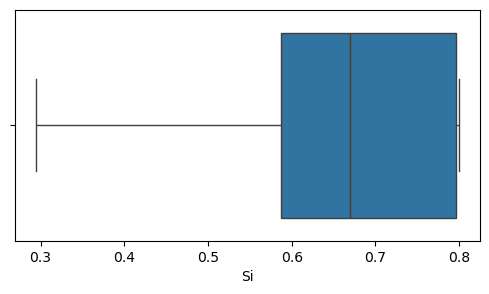

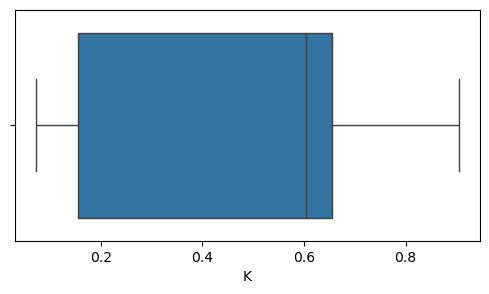

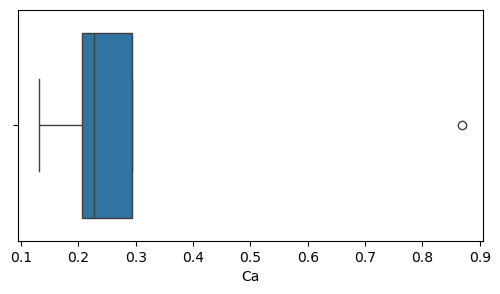

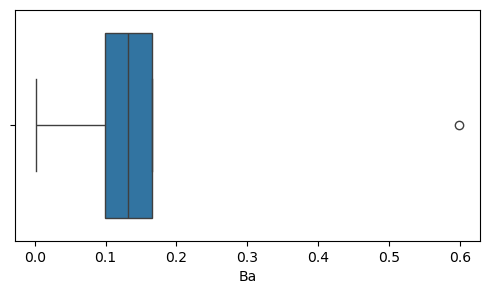

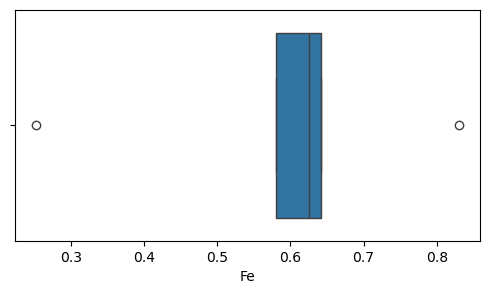

In [59]:
# Boxplots to check for outliers
for col in glass_df.columns[:-1]:  # skip target column
    plt.figure(figsize=(6,3))
    sns.boxplot(x=glass_df[col])
    plt.show()

In [60]:
# If missing values exist, we can fill with mean/median
glass_df.fillna(glass_df.median(), inplace=True)

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
glass_df['Type'] = le.fit_transform(glass_df['Type'])

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = glass_df.drop('Type', axis=1)
y = glass_df['Type']

X_scaled = scaler.fit_transform(X)

In [63]:
print(glass_df['Type'].value_counts())

Type
1    1
4    1
3    1
0    1
2    1
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0
           4       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Use

In [65]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming 'glass_df' is loaded from the previous cell
# Separate features (X) and target (y)
X = glass_df.drop('Type', axis=1)
y = glass_df['Type']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

bagging_model = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))


Bagging Accuracy: 0.0


In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.0
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\naidu\anaconda3\Myproject\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Use

In [67]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(n_estimators=100, random_state=42)
boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.0


In [68]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_boost)]})

print(results)

           Model  Accuracy
0  Random Forest       0.0
1        Bagging       0.0
2       Boosting       0.0


### Additional Notes:
Explain Bagging and Boosting methods. How is it different from each other. Explain how to handle imbalance in the data.

##### Bagging (Bootstrap Aggregating)
Bagging is an ensemble method that reduces variance by training multiple models independently on random subsets of the training data and then combining their predictions. Boosting: Boosting is an ensemble method that reduces bias and improves accuracy by training models sequentially, where each new model focuses on the errors made by the previous models. 2.Handling imbalance in data is a common challenge in machine learning and data, especially when one class has significantly fewer instances than others. Here’s a step‑by‑step guide on how to manage data imbalance.